In [1]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np 
from matplotlib.pyplot import figure
from sklearn.utils import shuffle
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support, confusion_matrix, precision_score, recall_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn import metrics
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV

Main objective of the analysis that specifies whether your model will be focused on prediction or interpretation and the benefits that your analysis provides to the business or stakeholders of this data:

The main objective of the airline satisfaction is prediction. I plan to develop a model that accurately predicts whether a passenger will be satisfied based on flight related features such as type of travel, amenities that come with the flight, service, etc. This predictive capability enables airlines to proactively identify areas of operations that can be improved to enhance customer experience which will have an effect on customer satisfaction. 

In [3]:
Airline_Train_df = pd.read_csv("C:/Users/jifsk/Downloads/archive(1)/train.csv")

In [4]:
Airline_Train_df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [5]:
Airline_Train_df['satisfaction'].value_counts()

satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64

<Axes: xlabel='satisfaction'>

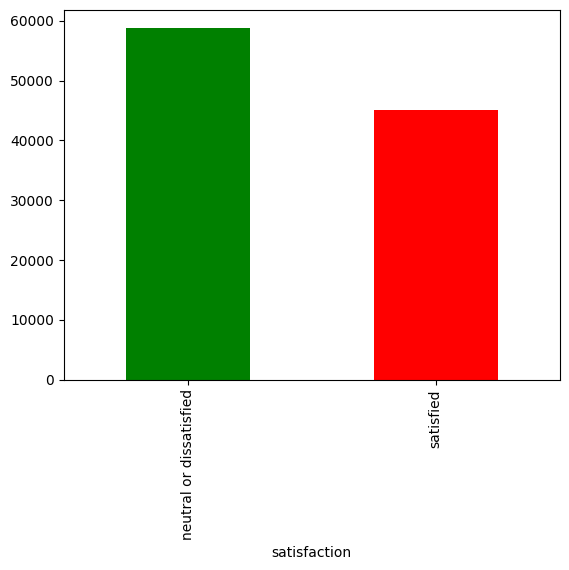

In [6]:
Airline_Train_df['satisfaction'].value_counts().plot.bar(color = ['green','red'])

In [7]:
Airline_test_df = pd.read_csv("C:/Users/jifsk/Downloads/archive(1)/test.csv")

In [8]:
Airline_test_df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [9]:
target_column = 'satisfaction'

Airline_test_df['satisfaction'].value_counts()

satisfaction
neutral or dissatisfied    14573
satisfied                  11403
Name: count, dtype: int64

Brief description of the data set you chose, a summary of its attributes, and an outline of what you are trying to accomplish with this analysis.

In [10]:
Airline_Train_df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,51951.500000,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,29994.645522,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [11]:
Airline_Train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

## Brief summary of data exploration and actions taken for data cleaning and feature engineering.

Since this dataset is fairly cleaned up before any data cleaning or feature engineering, one thing that I may do is create a delay status variable that involves Departure Delay in minutes to be 0 or 1, such as that if the departure delay was longer than x amount of minutes that it will equal to 1 instead.

In [12]:
Airline_Train_df.columns

Index(['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [13]:
Airline_Train_df['Departure Delay in Minutes'].describe()

count    103904.000000
mean         14.815618
std          38.230901
min           0.000000
25%           0.000000
50%           0.000000
75%          12.000000
max        1592.000000
Name: Departure Delay in Minutes, dtype: float64

In [14]:
Airline_Train_df['Departure Delay in Minutes'].value_counts()

Departure Delay in Minutes
0      58668
1       2948
2       2274
3       2009
4       1854
       ...  
390        1
314        1
343        1
724        1
337        1
Name: count, Length: 446, dtype: int64

In [15]:
Airline_Train_df['was_delayed'] = Airline_Train_df['Departure Delay in Minutes'].apply(lambda x: 1 if x > 15 else 0)
Airline_test_df['was_delayed'] = Airline_test_df['Departure Delay in Minutes'].apply(lambda x: 1 if x > 15 else 0)

In [16]:
Airline_Train_df['was_delayed'].value_counts()

was_delayed
0    80852
1    23052
Name: count, dtype: int64

In [17]:
Airline_test_df['was_delayed'].value_counts()

was_delayed
0    20291
1     5685
Name: count, dtype: int64

In [18]:
le = LabelEncoder()

In [19]:
Airline_Train_df['Gender'] = le.fit_transform(Airline_Train_df['Gender'])
Airline_test_df['Gender'] = le.fit_transform(Airline_test_df['Gender'])
Airline_Train_df['Gender'].value_counts()

Gender
0    52727
1    51177
Name: count, dtype: int64

In [20]:
Airline_Train_df['Customer Type'] = le.fit_transform(Airline_Train_df['Customer Type'])
Airline_test_df['Customer Type'] = le.fit_transform(Airline_test_df['Customer Type'])
Airline_Train_df['Customer Type'].value_counts()

Customer Type
0    84923
1    18981
Name: count, dtype: int64

In [21]:
Airline_Train_df['Type of Travel'] = le.fit_transform(Airline_Train_df['Type of Travel'])
Airline_test_df['Type of Travel'] = le.fit_transform(Airline_test_df['Type of Travel'])
Airline_Train_df['Type of Travel'].value_counts()

Type of Travel
0    71655
1    32249
Name: count, dtype: int64

In [22]:
Airline_Train_df['Class'] = le.fit_transform(Airline_Train_df['Class'])
Airline_test_df['Class'] = le.fit_transform(Airline_test_df['Class'])
Airline_Train_df['Class'].value_counts()

Class
0    49665
1    46745
2     7494
Name: count, dtype: int64

In [23]:
Airline_Train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 26 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  int64  
 3   Customer Type                      103904 non-null  int64  
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  int64  
 6   Class                              103904 non-null  int64  
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [24]:
Airline_Train_df.isnull().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction    

In [25]:
Airline_Train_df['Arrival Delay in Minutes'] = Airline_Train_df['Arrival Delay in Minutes'].fillna(Airline_Train_df['Arrival Delay in Minutes'].mean())
Airline_test_df['Arrival Delay in Minutes'] = Airline_test_df['Arrival Delay in Minutes'].fillna(Airline_test_df['Arrival Delay in Minutes'].mean())

In [26]:
Airline_test_df.isnull().sum()

Unnamed: 0                           0
id                                   0
Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
was_delayed              

In [27]:
Airline_Train_df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,was_delayed
0,0,70172,1,0,13,1,2,460,3,4,...,4,3,4,4,5,5,25,18.0,neutral or dissatisfied,1
1,1,5047,1,1,25,0,0,235,3,2,...,1,5,3,1,4,1,1,6.0,neutral or dissatisfied,0
2,2,110028,0,0,26,0,0,1142,2,2,...,4,3,4,4,4,5,0,0.0,satisfied,0
3,3,24026,0,0,25,0,0,562,2,5,...,2,5,3,1,4,2,11,9.0,neutral or dissatisfied,0
4,4,119299,1,0,61,0,0,214,3,3,...,3,4,4,3,3,3,0,0.0,satisfied,0


In [28]:
Airline_Train_df = Airline_Train_df.drop(['Departure Delay in Minutes','Arrival Delay in Minutes'], axis = 1)
Airline_test_df = Airline_test_df.drop(['Departure Delay in Minutes','Arrival Delay in Minutes'], axis = 1)

In [29]:
Airline_Train_df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,satisfaction,was_delayed
0,0,70172,1,0,13,1,2,460,3,4,...,5,5,4,3,4,4,5,5,neutral or dissatisfied,1
1,1,5047,1,1,25,0,0,235,3,2,...,1,1,1,5,3,1,4,1,neutral or dissatisfied,0
2,2,110028,0,0,26,0,0,1142,2,2,...,5,5,4,3,4,4,4,5,satisfied,0
3,3,24026,0,0,25,0,0,562,2,5,...,2,2,2,5,3,1,4,2,neutral or dissatisfied,0
4,4,119299,1,0,61,0,0,214,3,3,...,5,3,3,4,4,3,3,3,satisfied,0


## Summary of training at least three different classifier models, preferably of different nature in explainability and predictability. For example, you can start with a simple logistic regression as a baseline, adding other models or ensemble models. Preferably, all your models use the same training and test splits, or the same cross-validation method.

Splitting the datasets into X_train, X_test, y_train, y_test respectively

In [32]:
X_train = Airline_Train_df.drop(columns=[target_column])
y_train = Airline_Train_df[target_column]

In [33]:
X_test = Airline_test_df.drop(columns = [target_column])
y_test = Airline_test_df[target_column]

In [59]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[['Age','Flight Distance']] = scaler.fit_transform(X_train[['Age','Flight Distance']])
X_test[['Age','Flight Distance']] = scaler.transform(X_test[['Age','Flight Distance']])

In [61]:
model = LogisticRegression(random_state = 42,
                           max_iter = 10000,
                          solver = 'saga')

model.fit(X_train,y_train)
preds = model.predict(X_test)

In [62]:
accuracy_score(y_test, preds)

0.6240760702186634

In [66]:
accuracy = accuracy_score(y_test, preds)
# Assuming preds are already numeric (0 or 1)
precision, recall, fbeta, _ = precision_recall_fscore_support(
    y_test, preds, beta=5, pos_label=1, average='binary'
)

auc = roc_auc_score(y_test, preds)

# Print results
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F-beta Score (β=5): {fbeta:.2f}")
print(f"AUC: {auc:.2f}")

Accuracy: 0.62
Precision: 0.56
Recall: 0.71
F-beta Score (β=5): 0.71
AUC: 0.63


In [67]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluate
from sklearn.metrics import accuracy_score
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")

Random Forest Accuracy: 0.96


In [70]:
accuracy = accuracy_score(y_test, y_pred_rf)
# Assuming preds are already numeric (0 or 1)
precision, recall, fbeta, _ = precision_recall_fscore_support(
    y_test, y_pred_rf, beta=5, pos_label=1, average='binary'
)

auc = roc_auc_score(y_test, y_pred_rf)

# Print results
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F-beta Score (β=5): {fbeta:.2f}")
print(f"AUC: {auc:.2f}")

Accuracy: 0.96
Precision: 0.97
Recall: 0.94
F-beta Score (β=5): 0.94
AUC: 0.96


In [71]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

# Evaluate
print(f"Gradient Boosting Accuracy: {accuracy_score(y_test, y_pred_gb):.2f}")

Gradient Boosting Accuracy: 0.94


In [72]:
accuracy = accuracy_score(y_test, y_pred_gb)
# Assuming preds are already numeric (0 or 1)
precision, recall, fbeta, _ = precision_recall_fscore_support(
    y_test, y_pred_gb, beta=5, pos_label=1, average='binary'
)

auc = roc_auc_score(y_test, y_pred_gb)

# Print results
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F-beta Score (β=5): {fbeta:.2f}")
print(f"AUC: {auc:.2f}")

Accuracy: 0.94
Precision: 0.95
Recall: 0.92
F-beta Score (β=5): 0.93
AUC: 0.94


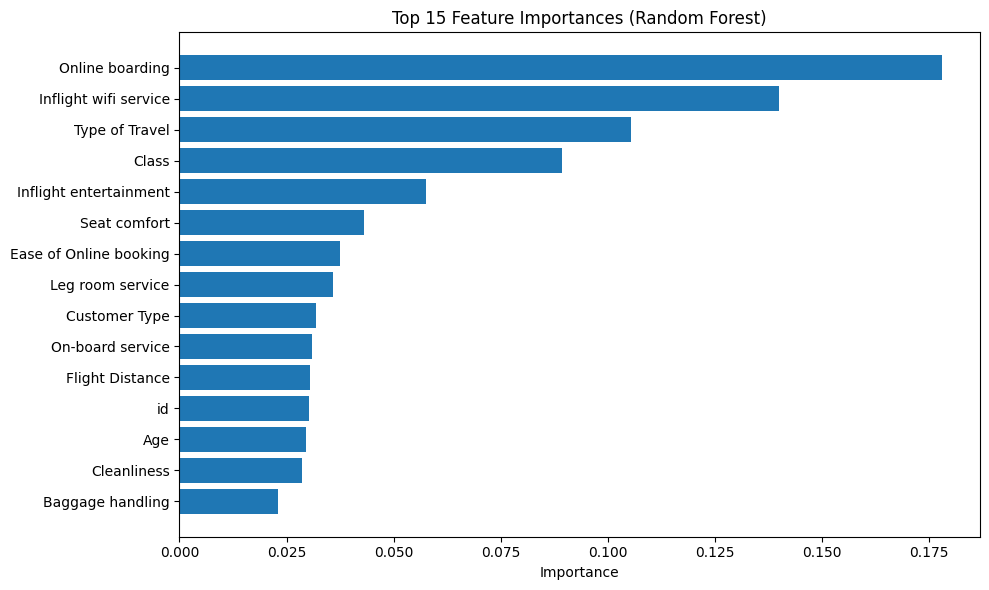

In [73]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf, labels=rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()
# Assuming rf_model is your trained Random Forest and X_train is your training data
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for plotting
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_df['Feature'][:15][::-1], feat_df['Importance'][:15][::-1])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()


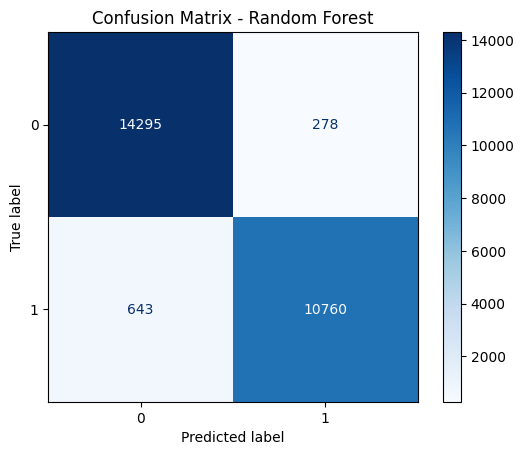

In [74]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf, labels=rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

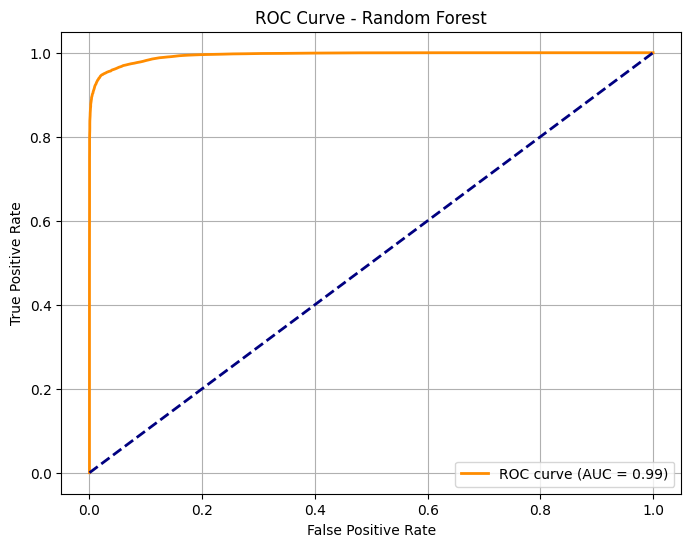

In [75]:
from sklearn.metrics import roc_curve, auc

# Make sure to get predicted probabilities
y_probs = rf_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [76]:
# Store metrics for each model
model_scores = {
    'Logistic Regression': {
        'Accuracy': 0.62,
        'Recall': 0.71,
        'F-beta': 0.71
    },
    'Gradient Boosting': {
        'Accuracy': 0.94,
        'Recall': 0.92,
        'F-beta': 0.93
    },
    'Random Forest': {
        'Accuracy': 0.96,
        'Recall': 0.97,
        'F-beta': 0.94
    }
}


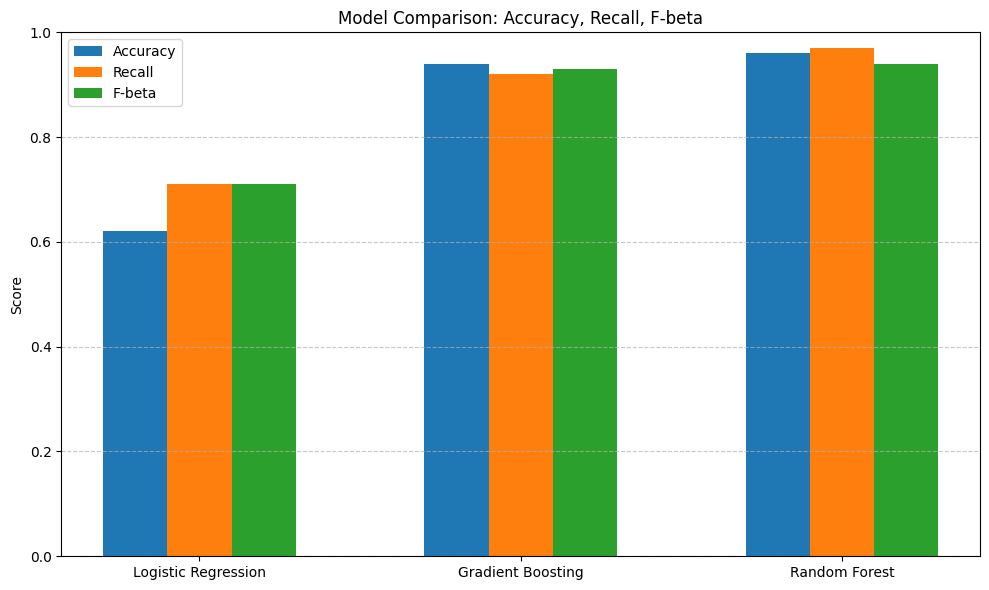

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data
models = list(model_scores.keys())
metrics = ['Accuracy', 'Recall', 'F-beta']

# Prepare data for plotting
values = [[model_scores[model][metric] for model in models] for metric in metrics]

x = np.arange(len(models))
width = 0.2

# Plot
plt.figure(figsize=(10,6))
for i, metric in enumerate(metrics):
    plt.bar(x + i*width, values[i], width=width, label=metric)

plt.xticks(x + width, models)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Comparison: Accuracy, Recall, F-beta")
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# A paragraph explaining which of your classifier models you recommend as a final model that best fits your needs in terms of accuracy and explainability.

The classifier model that I would recommend as a final model would probably be the Random Forest Classifier as it beats Logistic Regression and Gradient Boosting in all areas of predictability. It scored the highest on accuracy, precision, recall, f1 score, and auc with Gradient Boosting just slightly lower in percentages.

# Summary Key Findings and Insights, which walks your reader through the main drivers of your model and insights from your data derived from your classifier model.

The Random Forest Classifier outperformed the others across all metrics, demonstrating it's ability to capture complex patterns and nonlinear relationships in the data. The random forest model revealed the top factors influencing customer satisfaction such as inflight service quality, online boarding, type of travel and class. This provides to airlines the best things to focus on if they would like to improve customer satisfaction and start implementing those changes. This can also help reduce delays to meet customers expectations and enhance the overall experience.

# Suggestions for next steps in analyzing this data, which may include suggesting revisiting this model after adding specific data features that may help you achieve a better explanation or a better prediction.

I would do more advanced feature engineering to model satisfaction over the seasons or throughout the week to see if that plays a role in customer satisfaction. I would also use GridSearchCV if I had more time since doing this with such a large dataset will take time to optimize the models to get the best fit. I can also segment the class as economy may be more sensitive to delays and the type of travel that is done.